In [1]:
# 匯入 MNE 套件，它是專門處理腦波的工具箱
import mne

In [2]:
# 從 PhysioNet 下載 Sleep-EDF 第 ___ 位受試者、第 1 晚的資料，存到 data 資料夾
files = mne.datasets.sleep_physionet.age.fetch_data(
    subjects=[0],        # 受試者編號，Python 從 0 開始數
    recording=[1],         # 第幾晚（每個人錄了兩晚）
    path="../data",        # 存到哪裡：notebook 在 analysis 資料夾裡，".." 代表往上一層
    update_path=False,     # 不要改 MNE 的預設路徑設定
)

# 印出下載好的檔案路徑
print(files)

TypeError: fetch_data() got an unexpected keyword argument 'update_path'

In [4]:
# 從 PhysioNet 下載 Sleep-EDF 第 ___ 位受試者、第 1 晚的資料，存到 data 資料夾
files = mne.datasets.sleep_physionet.age.fetch_data(
    subjects=[0],        # 受試者編號，Python 從 0 開始數
    recording=[1],         # 第幾晚（每個人錄了兩晚）
    path="../data",        # 存到哪裡：notebook 在 analysis 資料夾裡，".." 代表往上一層

)

# 印出下載好的檔案路徑
print(files)

[['../data/physionet-sleep-data/SC4001E0-PSG.edf', '../data/physionet-sleep-data/SC4001EC-Hypnogram.edf']]


In [6]:
# 取出第一位受試者的 PSG 檔路徑
psg_file = files[0][0]

# 用 MNE 讀進 EDF 格式的腦波檔
raw = mne.io.read_raw_edf(psg_file)

# 印出這份資料的基本資訊
raw.info



Extracting EDF parameters from ../data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_37523/2607302738.py:5: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file)
/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_37523/2607302738.py:5: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file)
/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_37523/2607302738.py:5: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>

In [7]:
raw.times[-1]

np.float64(79499.99)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


/var/folders/qv/tvnfffyn2jv_gfygw9g7zy7m0000gn/T/ipykernel_37523/3517068426.py:2: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  fig = raw.plot(start=0, duration=30, show=False)


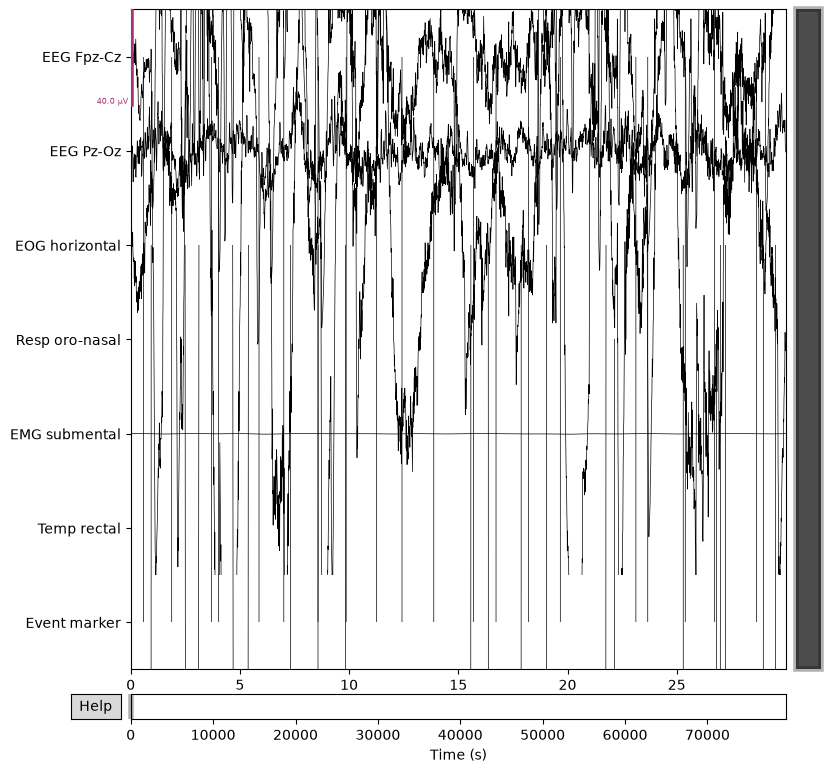

In [10]:
# 畫出從第 0 秒開始、長度 30 秒的腦波，先不要顯示（等一下要存檔）
fig = raw.plot(start=0, duration=30, show=False)

# 把圖存到 figures 資料夾（".." 代表往上一層）
fig.savefig("../figures/01_first_eeg.png", dpi=150)

# 在 notebook 裡顯示這張圖
fig